In [1]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torch
import torchvision

import numpy as np
import matplotlib.pyplot as plt

from src.MyDataset import MyDataset
from configs.config import *

import time
import datetime
import random

c:\Users\user\anaconda3\envs\imageClassification\lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: '[WinError 127] The specified procedure could not be found'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [2]:
def set_seed(seed):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)

In [3]:
transform = transforms.Compose([
    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(20),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [4]:
mini_batches_len = 10

In [5]:
train_set = MyDataset(TRAIN_CSV, TRAIN_IMG_DIR, transform=transform)
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)

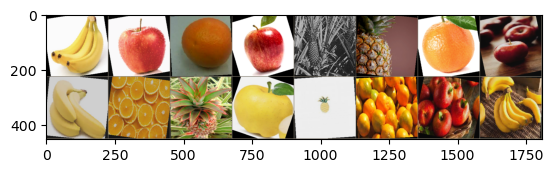

banana apple orange apple pineapple pineapple orange apple banana orange pineapple apple pineapple orange apple banana


In [6]:

def imshow(img):
    mean = torch.tensor([0.485,0.456,0.406])
    std = torch.tensor([0.229,0.224,0.225])

    img = img.clone()

    for i in range(3):
        img[i] = img[i] * std[i] + mean[i]

    npimg = img.numpy()
    plt.imshow(np.transpose(npimg,(1,2,0)))
    plt.show()

dataiter = iter(train_loader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images))

print(' '.join('%s' % CLASSES[labels[j]] for j in range(BATCH_SIZE)))

In [7]:
net = models.resnet18(weights="DEFAULT")

print(net)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [8]:
net.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(512,5)
)

for param in net.parameters():
    param.requires_grad = False

for param in net.layer4.parameters():
    param.requires_grad = True

for param in net.fc.parameters():
    param.requires_grad = True

In [9]:
criterion = nn.CrossEntropyLoss(
    label_smoothing=0.0
)
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, net.parameters()),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)


In [10]:
trainable = 0
total = 0

for name, param in net.named_parameters():
    total += param.numel()

    if param.requires_grad:
        trainable += param.numel()
        print(name)

print("----------------")
print("Trainable:", trainable)
print("Total:", total)

layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.weight
layer4.0.bn2.weight
layer4.0.bn2.bias
layer4.0.downsample.0.weight
layer4.0.downsample.1.weight
layer4.0.downsample.1.bias
layer4.1.conv1.weight
layer4.1.bn1.weight
layer4.1.bn1.bias
layer4.1.conv2.weight
layer4.1.bn2.weight
layer4.1.bn2.bias
fc.1.weight
fc.1.bias
----------------
Trainable: 8396293
Total: 11179077


In [11]:
start = time.time()

lossArr = []
train_accuracy_history = []
best_accuracy = 0.0

net.train()

for epoch in range(EPOCHS):
    running_loss = 0.0
    epoch_loss = 0.0

    correct = 0
    total = 0

    for i, data in enumerate(train_loader, 0):
        inputs, labels = data
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        # loss tracking
        running_loss += loss.item()
        epoch_loss += loss.item()
        # accuracy tracking
        _, predicted = torch.max(outputs.data, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if i % mini_batches_len == mini_batches_len-1:
            print(
                f'[{epoch+1}, {i+1}] loss: {running_loss/mini_batches_len:.4f}'
            )
            lossArr.append(
                running_loss/mini_batches_len
            )
            running_loss = 0.0

    epoch_loss = epoch_loss / len(train_loader)

    epoch_accuracy = 100 * correct / total

    train_accuracy_history.append(epoch_accuracy)


    scheduler.step(epoch_loss)


    # Save best model
    if epoch_accuracy > best_accuracy:

        best_accuracy = epoch_accuracy

        torch.save(
            net.state_dict(),
            MODEL_PATH
        )

        print(
            f"🔥 New best model saved! "
            f"Accuracy: {best_accuracy:.2f}%"
        )


    print(
        f"Epoch {epoch+1}: "
        f"Loss={epoch_loss:.4f}, "
        f"Accuracy={epoch_accuracy:.2f}%"
    )


end = time.time()

print(
    f'Finished Training!, Time: {end-start:.2f} sec...'
)

[1, 10] loss: 1.4842
[1, 20] loss: 0.7687
[1, 30] loss: 0.6423
[1, 40] loss: 0.5230
[1, 50] loss: 0.3516
[1, 60] loss: 0.3963
[1, 70] loss: 0.2350
[1, 80] loss: 0.2391
[1, 90] loss: 0.3044
[1, 100] loss: 0.1893
[1, 110] loss: 0.2544
[1, 120] loss: 0.2280
[1, 130] loss: 0.3148
[1, 140] loss: 0.2327
[1, 150] loss: 0.1818
🔥 New best model saved! Accuracy: 85.59%
Epoch 1: Loss=0.4177, Accuracy=85.59%
[2, 10] loss: 0.1093
[2, 20] loss: 0.1618
[2, 30] loss: 0.2021
[2, 40] loss: 0.1819
[2, 50] loss: 0.1882
[2, 60] loss: 0.1120
[2, 70] loss: 0.1470
[2, 80] loss: 0.1362
[2, 90] loss: 0.1495
[2, 100] loss: 0.2089
[2, 110] loss: 0.2156
[2, 120] loss: 0.1342
[2, 130] loss: 0.1505
[2, 140] loss: 0.1394
[2, 150] loss: 0.1264
🔥 New best model saved! Accuracy: 94.80%
Epoch 2: Loss=0.1554, Accuracy=94.80%
Finished Training!, Time: 176.47 sec...


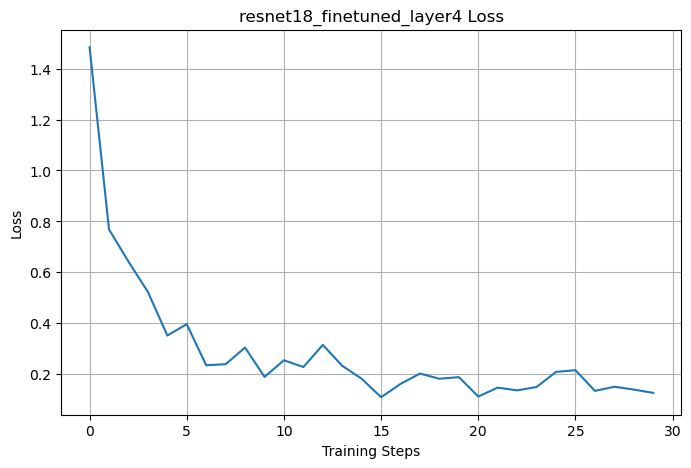

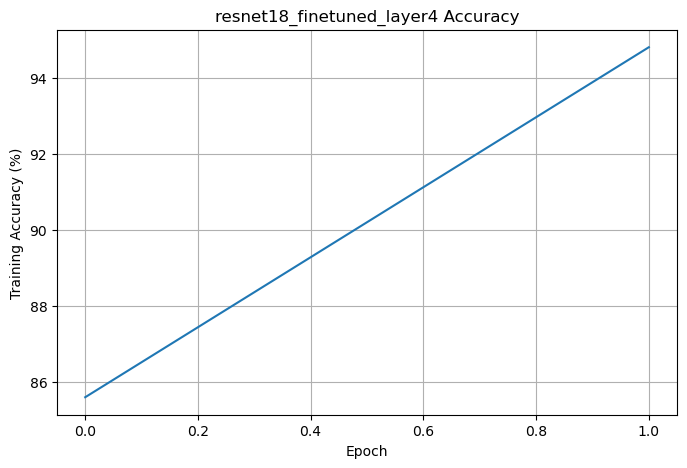

In [12]:
import os
import matplotlib.pyplot as plt

os.makedirs("./results/loss_curves", exist_ok=True)
os.makedirs("./results/accuracy_curves", exist_ok=True)

plt.figure(figsize=(8,5))

plt.plot(lossArr)

plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title(f"{MODEL_NAME} Loss")

plt.grid()

plt.savefig(
    f"./results/loss_curves/{MODEL_NAME}_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



# Accuracy curve

plt.figure(figsize=(8,5))
plt.plot(train_accuracy_history)

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy (%)")
plt.title(f"{MODEL_NAME} Accuracy")

plt.grid()

plt.savefig(
    f"./results/accuracy_curves/{MODEL_NAME}_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
experiment_path = f"./experiments/{MODEL_NAME}.txt"

with open(experiment_path, "w") as f:

    f.write(f"""
Experiment: {MODEL_NAME}

Date:
{datetime.datetime.now()}

====================
Dataset
====================

Training samples:
{len(train_set)}

Classes:
{CLASSES}


====================
Training Parameters
====================

Seed:
{SEED}

Batch size:
{BATCH_SIZE}

Epochs:
{EPOCHS}


====================
Optimizer
====================

Optimizer:
AdamW

Learning rate:
{LEARNING_RATE}

Weight decay:
{WEIGHT_DECAY}


====================
Loss
====================

CrossEntropyLoss
Label smoothing:
0.0


====================
Model
====================

Architecture:
ResNet18

Fine tuning:
Layer4 + FC


====================
Saved Model
====================

Path:
{MODEL_PATH}

Best Training Accuracy:
{best_accuracy:.2f}%
""")

print(f"Experiment saved to: {experiment_path}")

Experiment saved to: ./experiments/resnet18_finetuned_layer4.txt


In [14]:
datetime.now()

AttributeError: module 'datetime' has no attribute 'now'